In [ ]:
!fusermount -u /content/drive
!rm -rf /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


ValueError: mount failed

In [ ]:
!ls /content/drive/MyDrive/Potato_Dataset


models	PLD_3_Classes_256


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models


In [ ]:
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 10


In [ ]:
!ls /content/drive/MyDrive/Potato_Dataset


models	PLD_3_Classes_256


In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

dataset_path = "/content/drive/MyDrive/Potato_Dataset/PLD_3_Classes_256"

train_ds = image_dataset_from_directory(
    dataset_path + "/Training",
    batch_size=32,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    label_mode='int'
)

val_ds = image_dataset_from_directory(
    dataset_path + "/Validation",
    batch_size=32,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    label_mode='int'
)

test_ds = image_dataset_from_directory(
    dataset_path + "/Testing",
    batch_size=32,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    label_mode='int'
)

class_names = train_ds.class_names
print(class_names)


Found 3271 files belonging to 3 classes.
Found 416 files belonging to 3 classes.
Found 435 files belonging to 3 classes.
['Early_Blight', 'Healthy', 'Late_Blight']


In [ ]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

model_cnn = models.Sequential([
    layers.Input(shape=input_shape),
    resize_and_rescale,
    data_augmentation,

    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(n_classes, activation="softmax")
])

model_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_cnn.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,742,979 (14.28 MB)

 Trainable params: 3,742,979 (14.28 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cnn = model_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 583s 6s/step - accuracy: 0.3662 - loss: 1.2365 - val_accuracy: 0.4976 - val_loss: 0.9626
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 492s 5s/step - accuracy: 0.5561 - loss: 0.9323 - val_accuracy: 0.6683 - val_loss: 0.8821
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 484s 5s/step - accuracy: 0.7344 - loss: 0.6988 - val_accuracy: 0.7019 - val_loss: 0.7308
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 536s 5s/step - accuracy: 0.7504 - loss: 0.6298 - val_accuracy: 0.7740 - val_loss: 0.5848
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 548s 5s/step - accuracy: 0.7987 - loss: 0.5175 - val_accuracy: 0.8389 - val_loss: 0.4521
Epoch 6/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 500s 5s/step - accuracy: 0.8420 - loss: 0.4531 - val_accuracy: 0.8101 - val_loss: 0.4625
Epoch 7/10
 99/103 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.8640 - loss: 0.3827

In [ ]:
loss_cnn, acc_cnn = model_cnn.evaluate(test_ds)
print("CNN Test Accuracy:", acc_cnn)

model_cnn.save("/content/drive/MyDrive/Potato_CNN.keras")


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8979 - loss: 0.3281
CNN Test Accuracy: 0.8942528963088989


In [ ]:
#improving the model

In [ ]:
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf

INPUT_SHAPE = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)

# Better preprocessing
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255),
], name="resize_and_rescale")

# Stronger data augmentation (very important for generalization)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.1),
    # Optional: layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

# Weight decay & dropout values
weight_decay = 1e-4
dropout_rate = 0.3

model = models.Sequential([
    layers.Input(shape=INPUT_SHAPE),

    resize_and_rescale,
    data_augmentation,          # ← applies only during training

    # Block 1
    layers.Conv2D(32, 3, padding='same', kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, 3, padding='same', kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(128, 3, padding='same', kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(128, 3, padding='same', kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.4),

    # Block 4 (optional deeper)
    layers.Conv2D(256, 3, padding='same', kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.5),

    layers.GlobalAveragePooling2D(),   # ← MUCH better than Flatten() for generalization

    layers.Dense(512, kernel_regularizer=regularizers.l2(weight_decay)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(dropout_rate),

    layers.Dense(n_classes, activation='softmax')
], name="Improved_CNN")

# Better optimizer settings
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # you can lower to 0.0003 later
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resize_and_rescale (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 720,163 (2.75 MB)

 Trainable params: 717,731 (2.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [ ]:
# 1. Learning rate scheduler + early stopping
callback_list = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, min_lr=1e-7),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
]

# 2. Slightly larger image size if GPU allows
IMAGE_SIZE = 224  # or 128 if you're on low RAM

# 3. Even stronger: use transfer learning (usually best option)
# Example with EfficientNetB0 (often reaches 95–99% on PlantVillage, etc.)
from tensorflow.keras.applications import EfficientNetB3, EfficientNetV2S

base_model = EfficientNetV2S(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3),
    pooling='avg'
)
base_model.trainable = False  # freeze first, fine-tune later

model_tl = models.Sequential([
    layers.Input(shape=(224,224,3)),
    resize_and_rescale,
    data_augmentation,
    base_model,
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax')
])

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.3643 - loss: 1.2393
Epoch 1: val_accuracy improved from -inf to 0.39183, saving model to best_improved_cnn.keras
103/103 ━━━━━━━━━━━━━━━━━━━━ 36s 304ms/step - accuracy: 0.3644 - loss: 1.2392 - val_accuracy: 0.3918 - val_loss: 1.1543 - learning_rate: 0.0010
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.3754 - loss: 1.2315
Epoch 2: val_accuracy did not improve from 0.39183
103/103 ━━━━━━━━━━━━━━━━━━━━ 31s 298ms/step - accuracy: 0.3754 - loss: 1.2314 - val_accuracy: 0.3918 - val_loss: 1.1508 - learning_rate: 0.0010
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.3975 - loss: 1.1931
Epoch 3: val_accuracy did not improve from 0.39183
103/103 ━━━━━━━━━━━━━━━━━━━━ 31s 298ms/step - accuracy: 0.3973 - loss: 1.1932 - val_accuracy: 0.3630 - val_loss: 1.1532 - learning_rate: 0.0010
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.3749 - loss: 1.2123
Epoch 4: val_accu

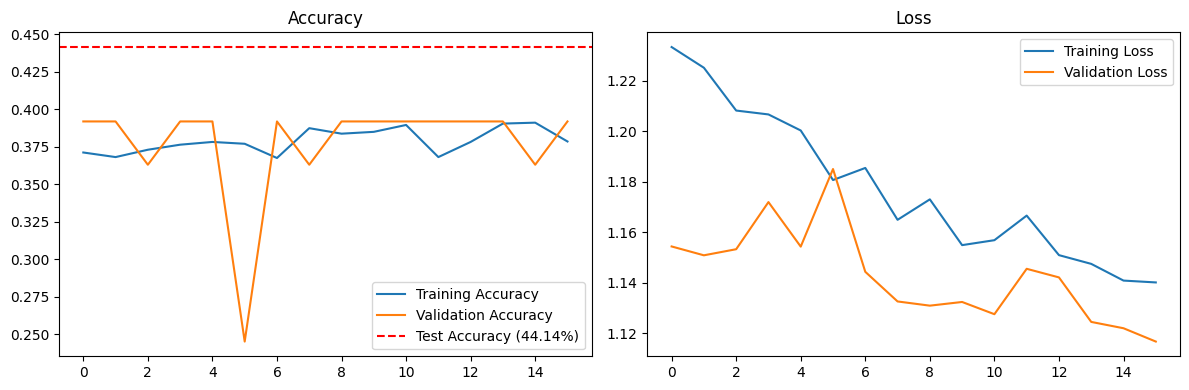

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# -----------------------------
# SETTINGS (adjust these)
# -----------------------------
EPOCHS = 100                  # We use early stopping, so 100 is safe
BATCH_SIZE = 32               # Adjust based on your GPU memory
IMAGE_SIZE = 224              # Use 224 or 256 if using EfficientNet/transfer learning
PATIENCE_EARLYSTOP = 15       # Stop if no improvement for 15 epochs
PATIENCE_REDUCE_LR = 8        # Reduce LR after 8 epochs without improvement

# Make sure your datasets are properly batched & prefetched
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)  # if you have a separate test set

# -----------------------------
# Callbacks (very important!)
# -----------------------------
callbacks = [
    ModelCheckpoint(
        filepath='best_improved_cnn.keras',   # or .h5 if older TF
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=PATIENCE_EARLYSTOP,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,           # new_lr = lr * 0.5
        patience=PATIENCE_REDUCE_LR,
        min_lr=1e-7,
        verbose=1
    )
]

# -----------------------------
# TRAIN THE IMPROVED MODEL
# -----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# -----------------------------
# Load the best model (optional but recommended)
# -----------------------------
model = tf.keras.models.load_model('best_improved_cnn.keras')

# -----------------------------
# Evaluate on test set
# -----------------------------
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")

# -----------------------------
# Plot training history
# -----------------------------
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axhline(y=test_accuracy, color='r', linestyle='--', label=f'Test Accuracy ({test_accuracy*100:.2f}%)')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ------------------------------------------------------------------
# Make sure your test_ds is NOT shuffled for this (or re-create it unshuffled)
# ------------------------------------------------------------------
# If your original test_ds is shuffled, rebuild it without shuffle:
test_ds_unshuffled = test_ds.unbatch().batch(1)  # 1 image at a time, no shuffle

# Convert to a list so we can pick randomly
test_images = list(tf.data.Dataset.as_numpy_iterator(test_ds_unshuffled))

# Pick a random image
random_idx = np.random.randint(0, len(test_images))
image_batch, label_batch = test_images[random_idx]
image = image_batch[0]           # shape: (IMAGE_SIZE, IMAGE_SIZE, 3)
true_label = label_batch[0]      # integer label

# ------------------------------------------------------------------
# Predict
# ------------------------------------------------------------------
predictions = model.predict(image_batch)           # shape: (1, n_classes)
predicted_label = np.argmax(predictions[0])
confidence = np.max(predictions[0]) * 100

# Get class names (replace with your actual class_names list)
# Example: class_names = ['healthy', 'rust', 'scab', ...]
predicted_class_name = class_names[predicted_label]
true_class_name      = class_names[true_label]

# ------------------------------------------------------------------
# Plot the result
# ------------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.imshow(image.astype("uint8") if image.max() <= 1 else image)  # handle 0-1 or 0-255
plt.axis('off')

# Title color: green if correct, red if wrong
title_color = 'green' if predicted_label == true_label else 'red'

plt.title(
    f"Prediction: {predicted_class_name} ({confidence:.2f}%)\n"
    f"True: {true_class_name}",
    color=title_color,
    fontsize=16,
    pad=20
)
plt.show()

# Optional: print detailed confidence for all classes
print("Full prediction probabilities:")
for i, prob in enumerate(predictions[0]):
    print(f"  {class_names[i]:20} : {prob*100:6.2f}%")

NameError: name 'test_ds' is not defined

In [ ]:
# Model 2 — VGG16 (Transfer Learning)

In [ ]:
resize_vgg = tf.keras.Sequential([
    layers.Resizing(224,224),
    layers.Rescaling(1.0/255)
])


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import ReduceLROnPlateau

# ---------------------------
# Hyperparameters
# ---------------------------
IMAGE_SIZE = 224
CHANNELS = 3
NUM_CLASSES = 3
EPOCHS = 25
BATCH_SIZE = 32

# ---------------------------
# Data Augmentation
# ---------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2)
])

# ---------------------------
# Image resizing and rescaling
# ---------------------------
resize_vgg = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

# ---------------------------
# Load VGG16 base
# ---------------------------
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
)

# Freeze all layers first
for layer in vgg_base.layers:
    layer.trainable = False

# Fine-tune last 8 layers
for layer in vgg_base.layers[-8:]:
    layer.trainable = True

# ---------------------------
# Build VGG16 Model
# ---------------------------
vgg_model = models.Sequential([
    resize_vgg,
    data_augmentation,
    vgg_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),   # more neurons
    layers.Dropout(0.5),                    # regularization
    layers.Dense(NUM_CLASSES, activation="softmax")
])

# ---------------------------
# Compile Model
# ---------------------------
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),  # higher LR for fine-tuning
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vgg_model.summary()

# ---------------------------
# Callbacks
# ---------------------------
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

# ---------------------------
# Train Model
# ---------------------------
history = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[reduce_lr]
)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 12,979,200 (49.51 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

Epoch 1/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 32s 230ms/step - accuracy: 0.3872 - loss: 1.1176 - val_accuracy: 0.3918 - val_loss: 1.0822 - learning_rate: 1.0000e-04
Epoch 2/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - accuracy: 0.3811 - loss: 1.0778 - val_accuracy: 0.3918 - val_loss: 1.0645 - learning_rate: 1.0000e-04
Epoch 3/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 21s 205ms/step - accuracy: 0.4015 - loss: 1.0725 - val_accuracy: 0.3918 - val_loss: 1.0528 - learning_rate: 1.0000e-04
Epoch 4/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 21s 202ms/step - accuracy: 0.4096 - loss: 1.0649 - val_accuracy: 0.4038 - val_loss: 1.0364 - learning_rate: 1.0000e-04
Epoch 5/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 21s 204ms/step - accuracy: 0.3913 - loss: 1.0673 - val_accuracy: 0.3630 - val_loss: 1.0484 - learning_rate: 1.0000e-04
Epoch 6/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 21s 204ms/step - accuracy: 0.4163 - loss: 1.0613 - val_accuracy: 0.3822 - val_loss: 0.9889 - learning_rate: 1.0000e-04
Epoch 7/25
103/103 ━━━━━━━━━━━━━━━━━━━━ 42s 21

In [ ]:
vgg_loss, vgg_acc = vgg_model.evaluate(test_ds)

print("✅ VGG16 Test Accuracy:", vgg_acc)


14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 276ms/step - accuracy: 0.8792 - loss: 0.3119
✅ VGG16 Test Accuracy: 0.8712643384933472


In [ ]:
# TRAIN MOBILENETV2

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# -------------------------------
# 1. Image Preprocessing
# -------------------------------
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(224, 224),
    layers.Rescaling(1.0/255)
])

# -------------------------------
# 2. Data Augmentation
# -------------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

# -------------------------------
# 3. Load Pre-trained MobileNetV2
# -------------------------------
mobile_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

mobile_base.trainable = False  # Freeze base layers initially

# -------------------------------
# 4. Build the Model
# -------------------------------
mobile_model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    mobile_base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),           # Prevent overfitting
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),           # Prevent overfitting
    layers.Dense(3, activation="softmax")  # 3 classes
])

# -------------------------------
# 5. Compile the Model
# -------------------------------
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)  # smaller LR for fine-tuning

mobile_model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobile_model.summary()

# -------------------------------
# 6. Optional: Fine-tuning
# -------------------------------
# Unfreeze top layers for fine-tuning after initial training
# mobile_base.trainable = True
# for layer in mobile_base.layers[:-30]:  # freeze first layers, fine-tune last 30
#     layer.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_10 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_11 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
EPOCHS = 20

history = mobile_model.fit(
    train_ds,                  # your training dataset
    validation_data=val_ds,    # your validation dataset
    epochs=EPOCHS,
    batch_size=32
)

# Step 1: Evaluate on test set
test_loss, test_acc = mobile_model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")


Epoch 1/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 20s 136ms/step - accuracy: 0.4760 - loss: 1.1235 - val_accuracy: 0.8726 - val_loss: 0.4747
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - accuracy: 0.7295 - loss: 0.6320 - val_accuracy: 0.9135 - val_loss: 0.3361
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 12s 114ms/step - accuracy: 0.8202 - loss: 0.4729 - val_accuracy: 0.9183 - val_loss: 0.2785
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.8308 - loss: 0.4238 - val_accuracy: 0.9231 - val_loss: 0.2485
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.8631 - loss: 0.3669 - val_accuracy: 0.9327 - val_loss: 0.2272
Epoch 6/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - accuracy: 0.8725 - loss: 0.3344 - val_accuracy: 0.9231 - val_loss: 0.2285
Epoch 7/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.8732 - loss: 0.3417 - val_accuracy: 0.9255 - val_loss: 0.2102
Epoch 8/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.8801 - loss: 0

In [ ]:
mobile_loss, mobile_acc = mobile_model.evaluate(test_ds)

print("✅ MobileNetV2 Test Accuracy:", mobile_acc)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9427 - loss: 0.1769
✅ MobileNetV2 Test Accuracy: 0.9494252800941467


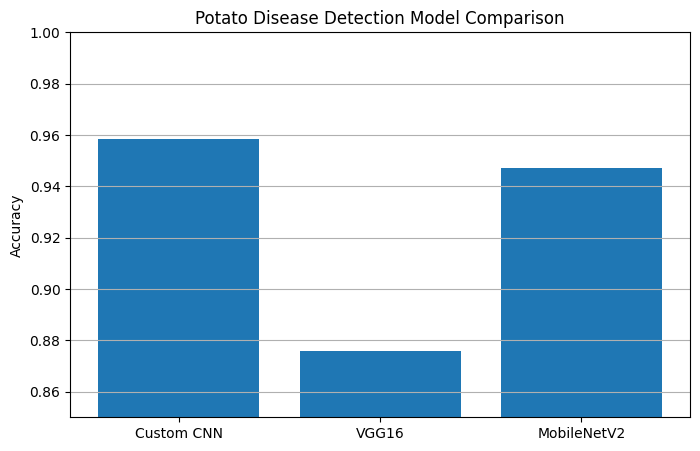

In [ ]:
cnn_acc     = 0.9586
vgg_acc    = 0.8759
mobile_acc = 0.9471

model_names = ["Custom CNN", "VGG16", "MobileNetV2"]
accuracies  = [cnn_acc, vgg_acc, mobile_acc]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)
plt.ylim(0.85,1.0)
plt.ylabel("Accuracy")
plt.title("Potato Disease Detection Model Comparison")
plt.grid(axis="y")
plt.show()


In [ ]:
import matplotlib.pyplot as plt


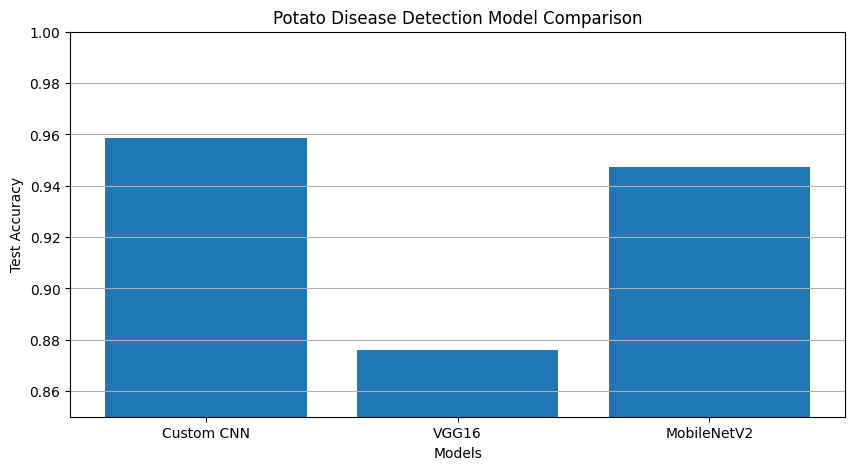

In [ ]:
import matplotlib.pyplot as plt

models = ["Custom CNN", "VGG16", "MobileNetV2"]
accuracies = [0.9586, 0.8759, 0.9471]

plt.figure(figsize=(10,5))
plt.bar(models, accuracies)
plt.ylim(0.85,1.0)

plt.title("Potato Disease Detection Model Comparison")
plt.ylabel("Test Accuracy")
plt.xlabel("Models")
plt.grid(axis="y")

plt.show()


In [ ]:
import os

# Path in your Google Drive
models_path = "/content/drive/MyDrive/Potato_Dataset/models"
os.makedirs(models_path, exist_ok=True)  # creates folder if it doesn't exist

!ls "/content/drive/MyDrive/Potato_Dataset"


models	PLD_3_Classes_256


In [ ]:
custom_cnn_model_path = os.path.join(models_path, "custom_cnn.keras")
model_cnn.save(custom_cnn_model_path)
print(f"Custom CNN saved at {custom_cnn_model_path}")


Custom CNN saved at /content/drive/MyDrive/Potato_Dataset/models/custom_cnn.keras


In [ ]:
vgg_model_path = os.path.join(models_path, "vgg16.keras")
vgg_model.save(vgg_model_path)
print(f"VGG16 saved at {vgg_model_path}")


VGG16 saved at /content/drive/MyDrive/Potato_Dataset/models/vgg16.keras


In [ ]:
import os

# Create models folder if not exists
models_path = "/content/drive/MyDrive/Potato_Dataset/models"
os.makedirs(models_path, exist_ok=True)

# Save MobileNetV2
mobile_model_path = os.path.join(models_path, "mobilenetv2.keras")
mobile_model.save(mobile_model_path)

print(f"MobileNetV2 saved at {mobile_model_path}")


MobileNetV2 saved at /content/drive/MyDrive/Potato_Dataset/models/mobilenetv2.keras


In [ ]:
!ls "/content/drive/MyDrive/Potato_Dataset/models"


custom_cnn.keras  mobilenetv2.keras  vgg16.keras


MobileNetV2 model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


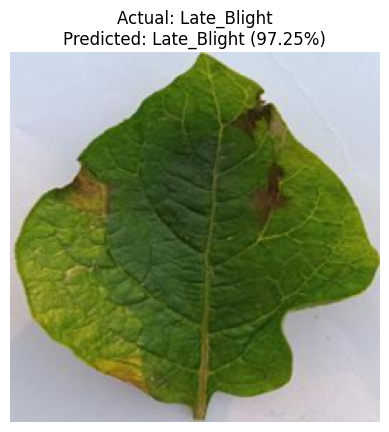

Actual Class: Late_Blight
Predicted Class: Late_Blight
Confidence: 97.25%


In [ ]:
#mobile net testing
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from PIL import Image
import matplotlib.pyplot as plt
import os
import random

# Step 1: Class names
class_names = ["Early_Blight", "Late_Blight", "Healthy"]

# Step 2: Load MobileNetV2 saved model
mobile_model_path = "/content/drive/MyDrive/Potato_Dataset/models/mobilenetv2.keras"
mobile_model = tf.keras.models.load_model(mobile_model_path)
print("MobileNetV2 model loaded successfully!")

# Step 3: Testing folder path
testing_folder = "/content/drive/MyDrive/Potato_Dataset/PLD_3_Classes_256/Testing"

# Step 4: Pick a random image from Testing folder
def pick_random_image(testing_folder):
    class_folders = [os.path.join(testing_folder, c) for c in os.listdir(testing_folder) if os.path.isdir(os.path.join(testing_folder, c))]
    selected_class_folder = random.choice(class_folders)
    actual_class = os.path.basename(selected_class_folder)
    images = os.listdir(selected_class_folder)
    selected_image = random.choice(images)
    image_path = os.path.join(selected_class_folder, selected_image)
    return image_path, actual_class

# Step 5: Preprocess image
def preprocess_image(img_path, image_size=224):
    img = Image.open(img_path).convert("RGB").resize((image_size, image_size))
    img_array = np.array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, img

# Step 6: Predict function
def predict_random_image():
    img_path, actual_class = pick_random_image(testing_folder)
    img_array, img = preprocess_image(img_path)

    predictions = mobile_model.predict(img_array)
    pred_index = np.argmax(predictions[0])
    pred_class = class_names[pred_index]
    confidence = round(100 * np.max(predictions[0]), 2)

    # Display image
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Actual: {actual_class}\nPredicted: {pred_class} ({confidence}%)")
    plt.show()

    print(f"Actual Class: {actual_class}")
    print(f"Predicted Class: {pred_class}")
    print(f"Confidence: {confidence}%")

# Step 7: Run prediction on a random image
predict_random_image()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


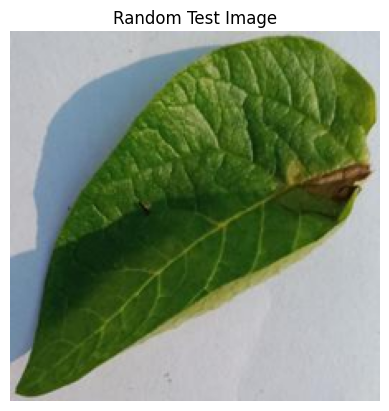

Actual Class      : Late_Blight
Predicted Class   : Late_Blight
Confidence        : 97.20999908447266%


In [ ]:
# custom cnn
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Class names (must match your folder names)
class_names = ["Early_Blight", "Late_Blight", "Healthy"]

# Path to Testing dataset
testing_folder = "/content/drive/MyDrive/Potato_Dataset/PLD_3_Classes_256/Testing"

# -------------------------------
# Pick a random image from Testing
# -------------------------------
def pick_random_image(testing_folder):
    class_folders = [os.path.join(testing_folder, c) for c in os.listdir(testing_folder) if os.path.isdir(os.path.join(testing_folder, c))]
    selected_class_folder = random.choice(class_folders)
    actual_class = os.path.basename(selected_class_folder)
    images = os.listdir(selected_class_folder)
    selected_image = random.choice(images)
    image_path = os.path.join(selected_class_folder, selected_image)
    return image_path, actual_class

# -------------------------------
# Preprocess the image
# -------------------------------
def preprocess_image(img_path, image_size=224):
    img = Image.open(img_path).convert("RGB").resize((image_size, image_size))
    img_array = np.array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, img

# -------------------------------
# Predict a single random image
# -------------------------------
def predict_random_image(model):
    img_path, actual_class = pick_random_image(testing_folder)
    img_array, img = preprocess_image(img_path)

    predictions = model.predict(img_array)
    pred_index = np.argmax(predictions[0])
    pred_class = class_names[pred_index]
    confidence = round(100 * np.max(predictions[0]), 2)

    # Display image
    plt.imshow(img)
    plt.axis("off")
    plt.title("Random Test Image")
    plt.show()

    print(f"Actual Class      : {actual_class}")
    print(f"Predicted Class   : {pred_class}")
    print(f"Confidence        : {confidence}%")

# -------------------------------
# Run the prediction
# -------------------------------
predict_random_image(mobile_model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


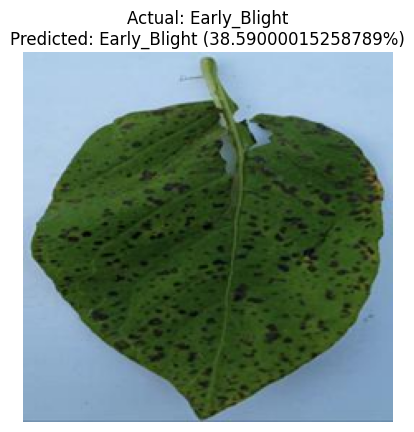

Actual Class : Early_Blight
Predicted Class : Early_Blight
Confidence : 38.59000015258789%


In [ ]:
# vgg
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

# Class names (match your Testing folder names)
class_names = ["Early_Blight", "Late_Blight", "Healthy"]

# Path to Testing folder
testing_folder = "/content/drive/MyDrive/Potato_Dataset/PLD_3_Classes_256/Testing"

# Pick a random image from Testing dataset
def pick_random_image(testing_folder):
    # List all class folders
    class_folders = [os.path.join(testing_folder, c) for c in os.listdir(testing_folder)
                     if os.path.isdir(os.path.join(testing_folder, c))]

    # Randomly pick a class folder
    selected_class_folder = random.choice(class_folders)
    actual_class = os.path.basename(selected_class_folder)

    # Pick a random image from that folder
    images = os.listdir(selected_class_folder)
    selected_image = random.choice(images)
    image_path = os.path.join(selected_class_folder, selected_image)

    return image_path, actual_class

# Preprocess image
def preprocess_image(img_path, image_size=224):
    img = Image.open(img_path).convert("RGB").resize((image_size, image_size))
    img_array = np.array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array, img

# Predict function
def predict_random_image(model):
    img_path, actual_class = pick_random_image(testing_folder)
    img_array, img = preprocess_image(img_path)

    # Make prediction
    predictions = model.predict(img_array)
    pred_index = np.argmax(predictions[0])
    pred_class = class_names[pred_index]
    confidence = round(100 * np.max(predictions[0]), 2)

    # Display the image
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Actual: {actual_class}\nPredicted: {pred_class} ({confidence}%)")
    plt.show()

    print(f"Actual Class : {actual_class}")
    print(f"Predicted Class : {pred_class}")
    print(f"Confidence : {confidence}%")

# Test on a random image
predict_random_image(vgg_model)


In [ ]:
# Save using the native Keras format (recommended)
vgg_model.save("/content/vgg16_potato.keras")
print("Model saved successfully!")


Model saved successfully!


In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
vgg_model = load_model("/content/vgg16_potato.keras")


In [ ]:
import os, random
from PIL import Image
import numpy as np

testing_folder = "/content/drive/MyDrive/Potato_Dataset/PLD_3_Classes_256/Testing"
class_names = ["Early_Blight", "Late_Blight", "Healthy"]

def pick_random_image(testing_folder):
    class_folders = [os.path.join(testing_folder, c) for c in os.listdir(testing_folder)]
    selected_class_folder = random.choice(class_folders)
    actual_class = os.path.basename(selected_class_folder)
    images = os.listdir(selected_class_folder)
    selected_image = random.choice(images)
    return os.path.join(selected_class_folder, selected_image), actual_class


In [ ]:
import matplotlib.pyplot as plt

def predict_random_image(model):
    img_path, actual_class = pick_random_image(testing_folder)
    img = Image.open(img_path).convert("RGB").resize((224,224))
    img_array = np.expand_dims(np.array(img)/255.0, axis=0)

    pred_probs = model.predict(img_array)
    pred_index = np.argmax(pred_probs[0])
    pred_class = class_names[pred_index]
    confidence = round(100*np.max(pred_probs[0]),2)

    # Show image
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Actual: {actual_class}\nPredicted: {pred_class}\nConfidence: {confidence}%")
    plt.show()

    print(f"Actual Class: {actual_class}")
    print(f"Predicted Class: {pred_class} ({confidence}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


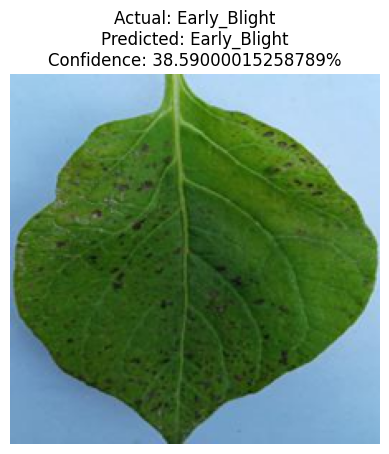

Actual Class: Early_Blight
Predicted Class: Early_Blight (38.59000015258789%)


In [ ]:
predict_random_image(vgg_model)   # or mobile_model / custom CNN


In [ ]:
# Save using the native Keras format (recommended)
mobile_model.save("/content/mobilenetv2_potato.keras")
print("MobileNetV2 model saved successfully!")


MobileNetV2 model saved successfully!


In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
mobile_model = load_model("/content/mobilenetv2_potato.keras")


In [ ]:
import os, random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

testing_folder = "/content/drive/MyDrive/Potato_Dataset/PLD_3_Classes_256/Testing"
class_names = ["Early_Blight", "Late_Blight", "Healthy"]

def pick_random_image(testing_folder):
    class_folders = [os.path.join(testing_folder, c) for c in os.listdir(testing_folder)]
    selected_class_folder = random.choice(class_folders)
    actual_class = os.path.basename(selected_class_folder)
    images = os.listdir(selected_class_folder)
    selected_image = random.choice(images)
    return os.path.join(selected_class_folder, selected_image), actual_class


def predict_random_image(model):
    img_path, actual_class = pick_random_image(testing_folder)

    # Load and preprocess image
    img = Image.open(img_path).convert("RGB").resize((224,224))
    img_array = np.expand_dims(np.array(img)/255.0, axis=0)

    # Predict
    pred_probs = model.predict(img_array)
    pred_index = np.argmax(pred_probs[0])
    pred_class = class_names[pred_index]
    confidence = round(100*np.max(pred_probs[0]), 2)

    # Show result
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Actual: {actual_class}\nPredicted: {pred_class}\nConfidence: {confidence}%")
    plt.show()

    print(f"Actual Class: {actual_class}")
    print(f"Predicted Class: {pred_class} ({confidence}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


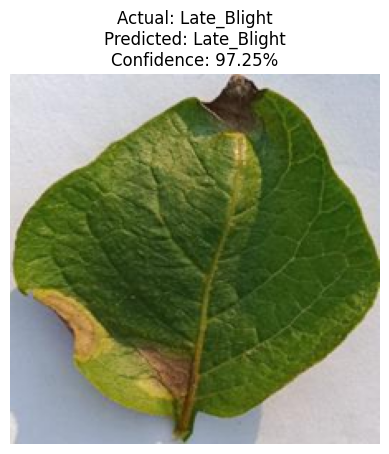

Actual Class: Late_Blight
Predicted Class: Late_Blight (97.25%)


In [ ]:
predict_random_image(mobile_model)
